# Q1

In [104]:
import os
import random
import string
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import cv2

random.seed(42)
np.random.seed(42)

In [160]:
BASE_DIR = os.path.dirname(os.getcwd())
DATA_DIR = os.path.join(BASE_DIR, 'data', 'captcha')
MAPSET_DIR = os.path.join(BASE_DIR, 'data', 'Mapset')

os.makedirs(os.path.join(DATA_DIR, 'generated_captchas'), exist_ok=True)
os.makedirs(os.path.join(DATA_DIR, 'noisy_captchas'), exist_ok=True)
os.makedirs(os.path.join(DATA_DIR, 'filtered_captchas'), exist_ok=True)

print(f"Data: {DATA_DIR}")
print(f"Mapset: {MAPSET_DIR}")

Data: e:\University_Projects\Vision\Computer-Vision-Course\HW2\data\captcha
Mapset: e:\University_Projects\Vision\Computer-Vision-Course\HW2\data\Mapset


In [167]:
def generate_random_text(length=4):
    characters = string.ascii_lowercase + string.digits
    return ''.join(random.choice(characters) for _ in range(length))

def create_captcha_image(text, size=(200, 80), font_size=50):
    image = Image.new('RGB', size, color='white')
    draw = ImageDraw.Draw(image)
    
    try:
        font = ImageFont.truetype("arial.ttf", font_size)
    except:
        font = ImageFont.load_default()
    
    bbox = draw.textbbox((0, 0), text, font=font)
    text_width = bbox[2] - bbox[0]
    text_height = bbox[3] - bbox[1]
    
    position = ((size[0] - text_width) // 2, (size[1] - text_height) // 2)
    
    draw.text(position, text, fill='black', font=font)
    
    return image

captcha_data = []

for i in range(1, 21):
    text = generate_random_text(4)
    
    image = create_captcha_image(text)
    
    filename = f"captcha_{text}.png"
    filepath = os.path.join(DATA_DIR, 'generated_captchas', filename)
    image.save(filepath)
    
    captcha_data.append({
        'id': i,
        'text': text,
        'filename': filename
    })
    
    print(f"Image {i:02d} generated: {text} -> {filename}")

print(f"\nAll 20 images were saved in {os.path.join(DATA_DIR, 'generated_captchas')}")

Image 01 generated: hbrp -> captcha_hbrp.png
Image 02 generated: oig8 -> captcha_oig8.png
Image 03 generated: f1cb -> captcha_f1cb.png
Image 04 generated: fno6 -> captcha_fno6.png
Image 05 generated: b9m8 -> captcha_b9m8.png
Image 06 generated: 0o2r -> captcha_0o2r.png
Image 07 generated: ak1v -> captcha_ak1v.png
Image 08 generated: rjnv -> captcha_rjnv.png
Image 09 generated: gfyg -> captcha_gfyg.png
Image 10 generated: wwqc -> captcha_wwqc.png
Image 11 generated: 38hy -> captcha_38hy.png
Image 12 generated: f9sx -> captcha_f9sx.png
Image 13 generated: meco -> captcha_meco.png
Image 14 generated: sfog -> captcha_sfog.png
Image 15 generated: yr3x -> captcha_yr3x.png
Image 16 generated: kxwn -> captcha_kxwn.png
Image 17 generated: rek8 -> captcha_rek8.png
Image 18 generated: pk3y -> captcha_pk3y.png
Image 19 generated: r9ou -> captcha_r9ou.png
Image 20 generated: docu -> captcha_docu.png

All 20 images were saved in e:\University_Projects\Vision\Computer-Vision-Course\HW2\data\captcha\g

In [83]:
df = pd.DataFrame(captcha_data)

csv_path = os.path.join(DATA_DIR, 'captcha_labels.csv')
df.to_csv(csv_path, index=False, encoding='utf-8')

df.head()

,id,text,filename
0,1,hbrp,captcha_hbrp.png
1,2,oig8,captcha_oig8.png
2,3,f1cb,captcha_f1cb.png
3,4,fno6,captcha_fno6.png
4,5,b9m8,captcha_b9m8.png


Noise was added to all images

All noisy images were saved in e:\University_Projects\Vision\Computer-Vision-Course\HW2\data\captcha\noisy_captchas


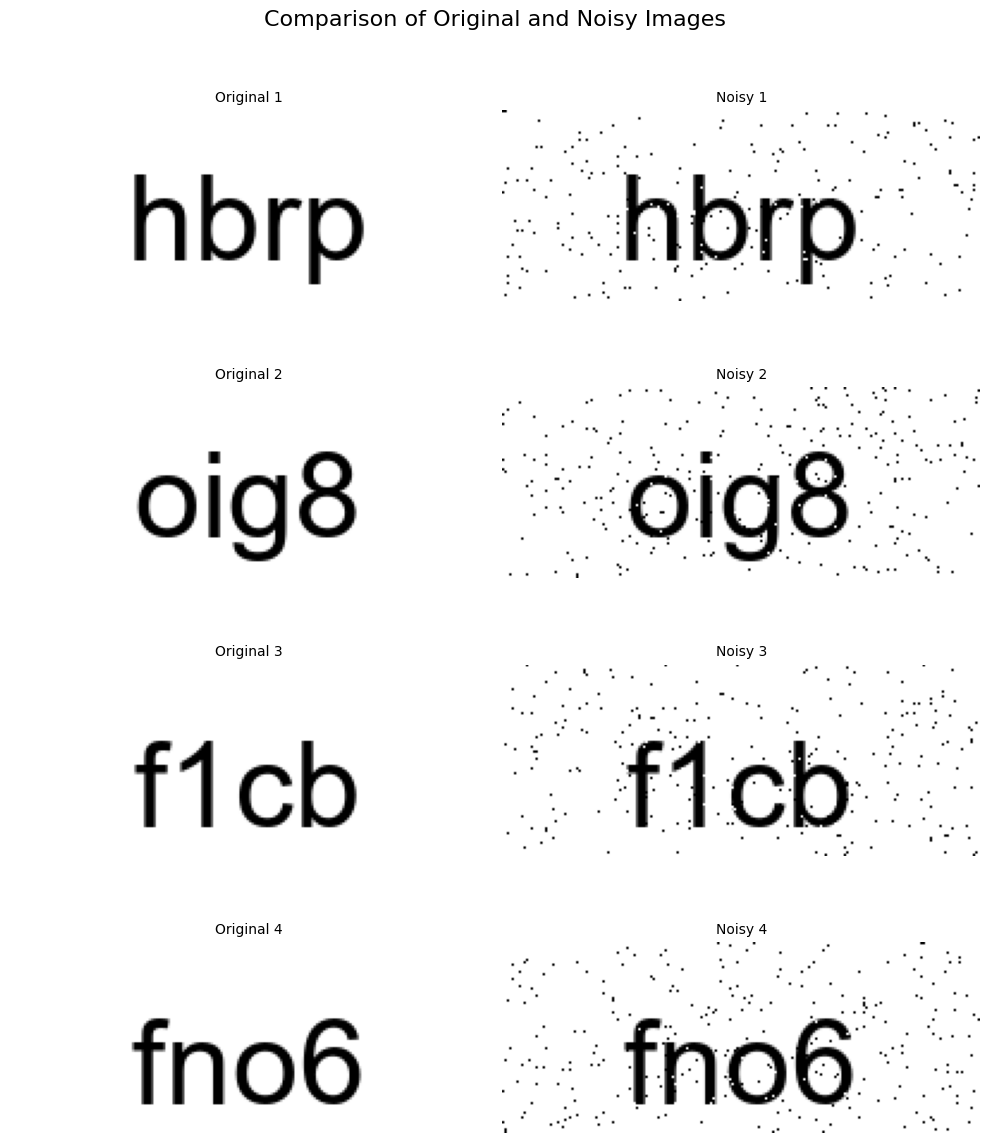

In [84]:
def add_salt_pepper_noise(image, salt_prob=0.03, pepper_prob=0.03):
    img_array = np.array(image)
    
    salt_mask = np.random.random(img_array.shape[:2]) < salt_prob/2
    img_array[salt_mask] = 255
    
    pepper_mask = np.random.random(img_array.shape[:2]) < pepper_prob/2
    img_array[pepper_mask] = 0
    
    return Image.fromarray(img_array)

for i in range(1, 21):
    filename = f"captcha_{captcha_data[i-1]['text']}.png"
    
    original_path = os.path.join(DATA_DIR, 'generated_captchas', filename)
    image = Image.open(original_path)
    
    noisy_image = add_salt_pepper_noise(image, salt_prob=0.03, pepper_prob=0.03)
    
    noisy_path = os.path.join(DATA_DIR, 'noisy_captchas', filename)
    noisy_image.save(noisy_path)
    
print(f"Noise was added to all images")

print(f"\nAll noisy images were saved in {os.path.join(DATA_DIR, 'noisy_captchas')}")

fig, axes = plt.subplots(4, 2, figsize=(10, 12))
fig.suptitle('Comparison of Original and Noisy Images', fontsize=16, y=0.995)

for idx in range(4):
    filename = f"captcha_{captcha_data[idx]['text']}.png"
    
    original = Image.open(os.path.join(DATA_DIR, 'generated_captchas', filename))
    noisy = Image.open(os.path.join(DATA_DIR, 'noisy_captchas', filename))
    
    axes[idx, 0].imshow(original, cmap='gray')
    axes[idx, 0].set_title(f'Original {idx+1}', fontsize=10)
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(noisy, cmap='gray')
    axes[idx, 1].set_title(f'Noisy {idx+1}', fontsize=10)
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()

**Gaussian blur** is a smoothing technique used to reduce noise and detail in an image. It works by averaging each pixel with its neighboring pixels, but instead of using a simple average, it uses weights derived from a Gaussian (bell‑shaped) distribution.

This means:

- Pixels closer to the center have higher weight
- Pixels farther from the center have smaller weight
- The blur is smooth and natural

When applied to your noisy CAPTCHAs:

- The random salt‑and‑pepper noise becomes less intense
- The image appears smoother
- Sharp, spike-like noise is reduced
- But the blur may slightly reduce text sharpness too  
  
The Gaussian blur operation effectively reduced random pixel-level variations introduced by the salt-and-pepper noise, but it also caused a slight loss of edge sharpness around character boundaries. This trade-off between noise suppression and detail preservation is a central topic in image restoration and will be further analyzed in subsequent sections.

In [85]:
def apply_gaussian_filter(image, kernel_size=3, sigma=0):
    img_array = np.array(image)
    blurred = cv2.GaussianBlur(img_array, (kernel_size, kernel_size), sigma)
    return Image.fromarray(blurred)

Gaussian filter applied to all images
All filtered images were saved in e:\University_Projects\Vision\Computer-Vision-Course\HW2\data\captcha\filtered_captchas


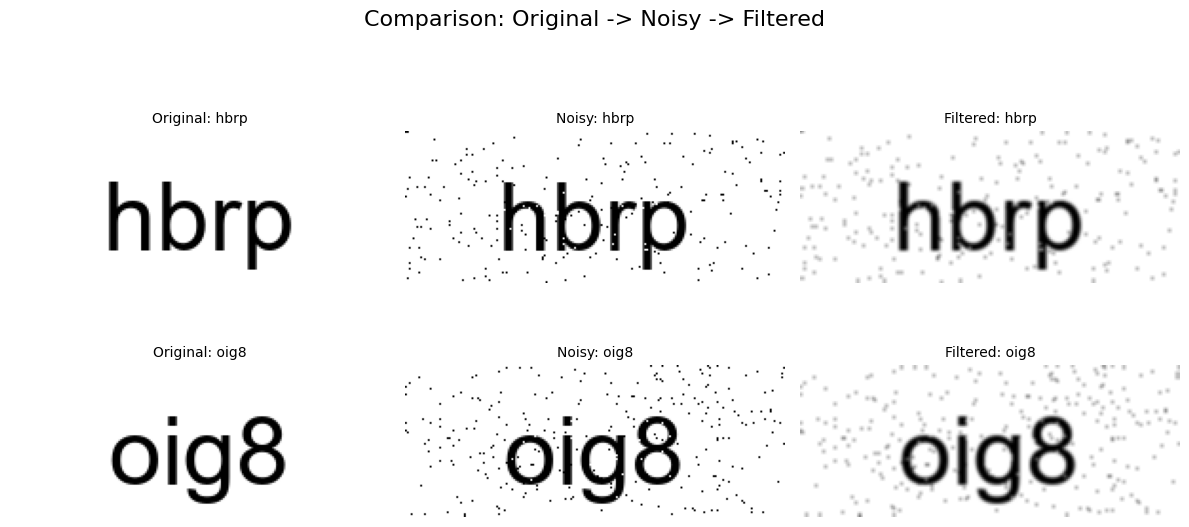

In [130]:
for i in range(1, 21):
    filename = f"captcha_{captcha_data[i-1]['text']}.png"
    
    noisy_path = os.path.join(DATA_DIR, 'noisy_captchas', filename)
    noisy_image = Image.open(noisy_path)
    
    filtered_image = apply_gaussian_filter(noisy_image, kernel_size=3, sigma=0)
    
    filtered_path = os.path.join(DATA_DIR, 'filtered_captchas', filename)
    filtered_image.save(filtered_path)

print("Gaussian filter applied to all images")
print(f"All filtered images were saved in {os.path.join(DATA_DIR, 'filtered_captchas')}")

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
fig.suptitle('Comparison: Original -> Noisy -> Filtered', fontsize=16, y=0.995)

for idx in range(2):
    filename = f"captcha_{captcha_data[idx]['text']}.png"
    text = df[df['filename'] == filename]['text'].values[0]
    
    original = Image.open(os.path.join(DATA_DIR, 'generated_captchas', filename))
    noisy = Image.open(os.path.join(DATA_DIR, 'noisy_captchas', filename))
    filtered = Image.open(os.path.join(DATA_DIR, 'filtered_captchas', filename))
    
    axes[idx, 0].imshow(original, cmap='gray')
    axes[idx, 0].set_title(f'Original: {text}', fontsize=10)
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(noisy, cmap='gray')
    axes[idx, 1].set_title(f'Noisy: {text}', fontsize=10)
    axes[idx, 1].axis('off')
    
    axes[idx, 2].imshow(filtered, cmap='gray')
    axes[idx, 2].set_title(f'Filtered: {text}', fontsize=10)
    axes[idx, 2].axis('off')

plt.tight_layout()
plt.show()


# Q2

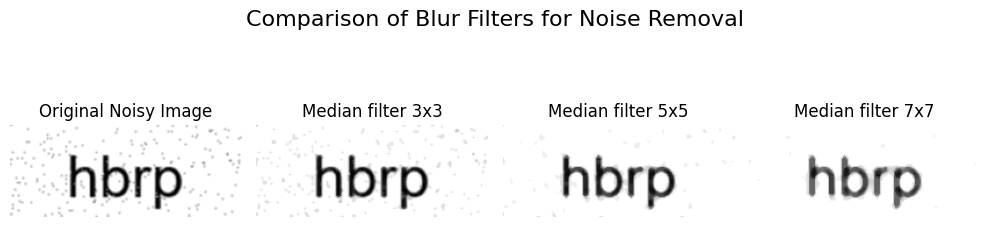

In [127]:
def apply_median_filter(image, kernel_size=3):
    img_array = np.array(image)
    denoised = cv2.medianBlur(img_array, kernel_size)
    return Image.fromarray(denoised)
    

sample_noisy = Image.open(os.path.join(DATA_DIR, 'filtered_captchas', f"captcha_{captcha_data[0]['text']}.png"))

blur_3x3 = apply_median_filter(sample_noisy, kernel_size=3)
blur_5x5 = apply_median_filter(sample_noisy, kernel_size=5)
blur_7x7 = apply_median_filter(sample_noisy, kernel_size=7)

fig, axes = plt.subplots(1, 4, figsize=(10, 3))
fig.suptitle('Comparison of Blur Filters for Noise Removal', fontsize=16)

axes[0].imshow(sample_noisy, cmap='gray')
axes[0].set_title('Original Noisy Image')
axes[0].axis('off')

axes[1].imshow(blur_3x3, cmap='gray')
axes[1].set_title('Median filter 3x3')
axes[1].axis('off')

axes[2].imshow(blur_5x5, cmap='gray')
axes[2].set_title('Median filter 5x5')
axes[2].axis('off')

axes[3].imshow(blur_7x7, cmap='gray')
axes[3].set_title('Median filter 7x7')
axes[3].axis('off')

plt.tight_layout()
plt.show()

In [128]:
print("\nApplying Meidan filter 3*3 to all filtered images...")
denoised_dir = os.path.join(DATA_DIR, 'denoised_captchas')
os.makedirs(denoised_dir, exist_ok=True)

for i in range(1, 21):
    filename = f"captcha_{captcha_data[i-1]['text']}.png"
    noisy_img = Image.open(os.path.join(DATA_DIR, 'filtered_captchas', filename))
    denoised = apply_median_filter(noisy_img, kernel_size=3)
    denoised.save(os.path.join(denoised_dir, filename))

print(f"Filtered images saved in {denoised_dir}")


Applying Meidan filter 3*3 to all filtered images...
Filtered images saved in e:\University_Projects\Vision\Computer-Vision-Course\HW2\data\captcha\denoised_captchas


In [89]:
def apply_sharpen_filter(image):
    img_array = np.array(image)

    kernel_sharpen = np.array([[0, -1, 0],
                               [-1, 5, -1],
                               [0, -1, 0]])

    sharpened = cv2.filter2D(img_array, -1, kernel_sharpen)

    return Image.fromarray(sharpened)

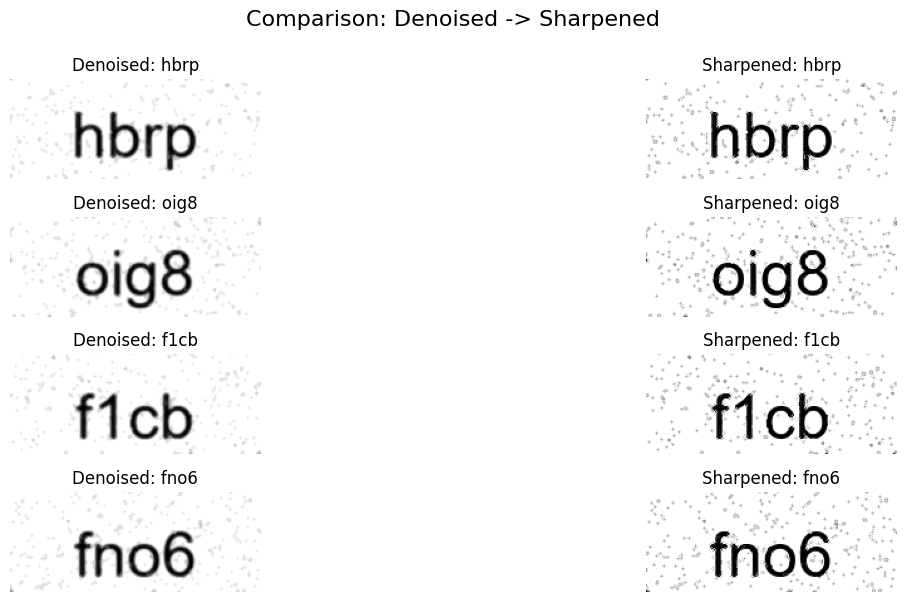


Applying sharpening filter to all images...
Sharpened images saved in e:\University_Projects\Vision\Computer-Vision-Course\HW2\data\captcha\sharpened_captchas


In [129]:
fig, axes = plt.subplots(4, 2, figsize=(16, 6))
fig.suptitle('Comparison: Denoised -> Sharpened', fontsize=16, y=0.995)

for idx in range(4):
    filename = f"captcha_{captcha_data[idx]['text']}.png"
    sample_img = Image.open(os.path.join(DATA_DIR, 'denoised_captchas', filename))
    
    sharpened = apply_sharpen_filter(sample_img)
    
    axes[idx, 0].imshow(sample_img, cmap='gray')
    axes[idx, 0].set_title(f"Denoised: {captcha_data[idx]['text']}")
    axes[idx, 0].axis('off')

    axes[idx, 1].imshow(sharpened, cmap='gray')
    axes[idx, 1].set_title(f"Sharpened: {captcha_data[idx]['text']}")
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()

print("\nApplying sharpening filter to all images...")
sharpened_dir = os.path.join(DATA_DIR, 'sharpened_captchas')
os.makedirs(sharpened_dir, exist_ok=True)

for i in range(1, 21):
    filename = f"captcha_{captcha_data[i-1]['text']}.png"
    denoised_img = Image.open(os.path.join(denoised_dir, filename))
    sharpened = apply_sharpen_filter(denoised_img)
    
    sharpened.save(os.path.join(sharpened_dir, filename))

print(f"Sharpened images saved in {sharpened_dir}")


In [141]:
def binarize_and_clean(image):
    min_component_size = 40
    
    gray = image.convert("L")
    img_array = np.array(gray)
    
    _, binary = cv2.threshold(img_array, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)    
    
    cleaned = np.zeros_like(binary)
    
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= min_component_size:
            cleaned[labels == i] = 255
    
    return Image.fromarray(cleaned)

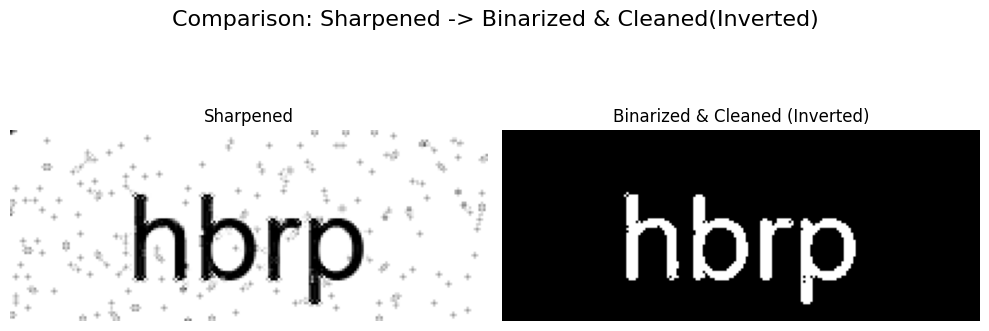


Applying binarization and cleaning to all images...
Binarized and cleaned images saved in e:\University_Projects\Vision\Computer-Vision-Course\HW2\data\captcha\binarized_captchas


In [142]:
sample_sharp = Image.open(os.path.join(sharpened_dir, f"captcha_{captcha_data[0]['text']}.png"))
bin_sample = binarize_and_clean(sample_sharp)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Comparison: Sharpened -> Binarized & Cleaned(Inverted)', fontsize=16, y=0.995)
axes[0].imshow(sample_sharp, cmap='gray')
axes[0].set_title("Sharpened")
axes[0].axis('off')

axes[1].imshow(bin_sample, cmap='gray')
axes[1].set_title("Binarized & Cleaned (Inverted)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("\nApplying binarization and cleaning to all images...")
cleaned_dir = os.path.join(DATA_DIR, 'binarized_captchas')
os.makedirs(cleaned_dir, exist_ok=True)

for i in range(1, 21):
    filename = f"captcha_{captcha_data[i-1]['text']}.png"
    sharp_img = Image.open(os.path.join(sharpened_dir, filename))
    cleaned = binarize_and_clean(sharp_img)
    
    cleaned.save(os.path.join(cleaned_dir, filename))

print(f"Binarized and cleaned images saved in {cleaned_dir}")

Creating overall comparison image of preprocessing stages


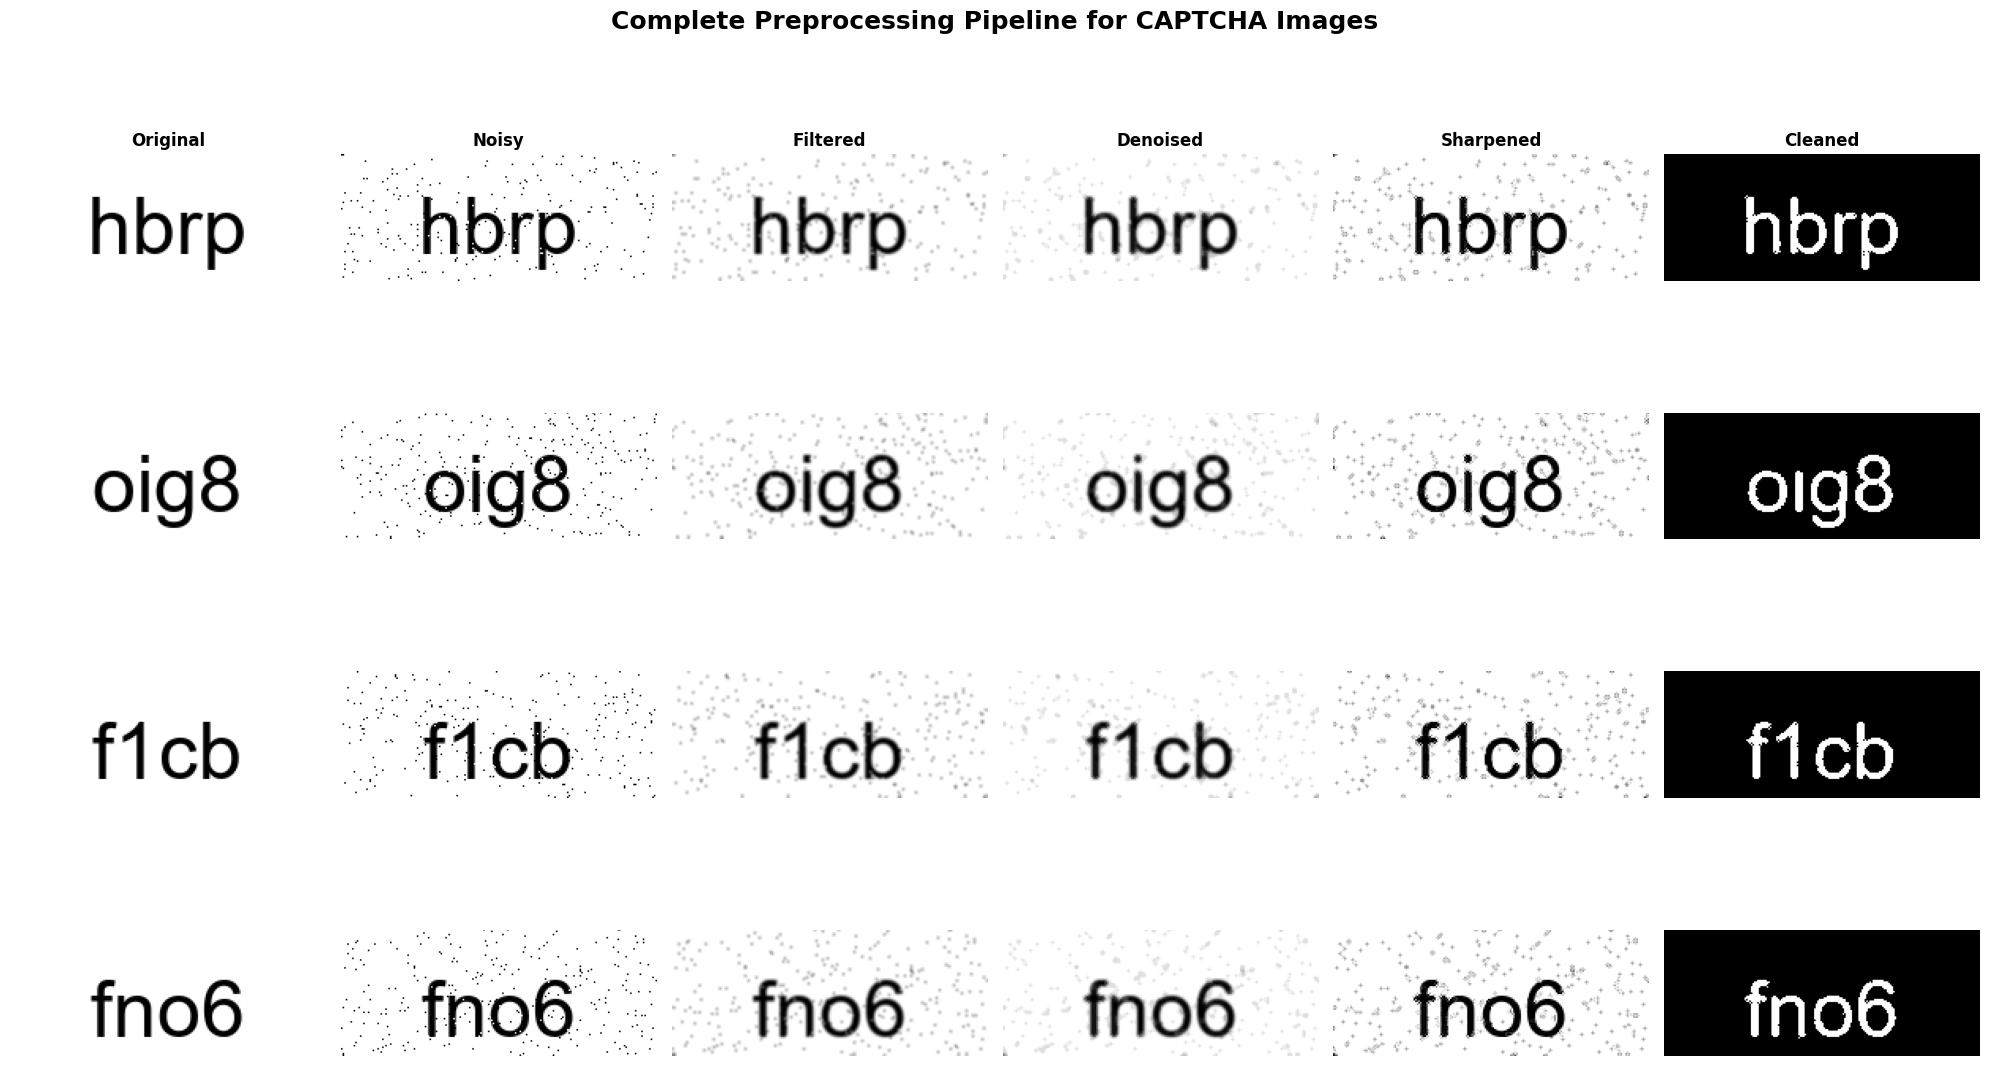

In [143]:
print("Creating overall comparison image of preprocessing stages")

fig = plt.figure(figsize=(20, 12))

for idx in range(4):
    filename = f"captcha_{captcha_data[idx]['text']}.png"
    
    original = Image.open(os.path.join(DATA_DIR, 'generated_captchas', filename))
    noisy = Image.open(os.path.join(DATA_DIR, 'noisy_captchas', filename))
    filtered = Image.open(os.path.join(DATA_DIR, 'filtered_captchas', filename))
    denoised = Image.open(os.path.join(DATA_DIR, 'denoised_captchas', filename))
    sharpened = Image.open(os.path.join(DATA_DIR, 'sharpened_captchas', filename))
    cleaned = Image.open(os.path.join(DATA_DIR, 'binarized_captchas', filename))
    
    row = idx
    
    ax1 = fig.add_subplot(4, 6, row*6 + 1)
    ax1.imshow(original, cmap='gray')
    if idx == 0:
        ax1.set_title('Original', fontsize=12, fontweight='bold')
    ax1.set_ylabel(f'Sample {idx+1}', fontsize=11)
    ax1.axis('off')
    
    ax2 = fig.add_subplot(4, 6, row*6 + 2)
    ax2.imshow(noisy, cmap='gray')
    if idx == 0:
        ax2.set_title('Noisy', fontsize=12, fontweight='bold')
    ax2.axis('off')
    
    ax3 = fig.add_subplot(4, 6, row*6 + 3)
    ax3.imshow(filtered, cmap='gray')
    if idx == 0:
        ax3.set_title('Filtered', fontsize=12, fontweight='bold')
    ax3.axis('off')
    
    ax4 = fig.add_subplot(4, 6, row*6 + 4)
    ax4.imshow(denoised, cmap='gray')
    if idx == 0:
        ax4.set_title('Denoised', fontsize=12, fontweight='bold')
    ax4.axis('off')
    
    ax5 = fig.add_subplot(4, 6, row*6 + 5)
    ax5.imshow(sharpened, cmap='gray')
    if idx == 0:
        ax5.set_title('Sharpened', fontsize=12, fontweight='bold')
    ax5.axis('off')

    ax6 = fig.add_subplot(4, 6, row*6 + 6)
    ax6.imshow(cleaned, cmap='gray')
    if idx == 0:
        ax6.set_title('Cleaned', fontsize=12, fontweight='bold')
    ax6.axis('off')

fig.suptitle('Complete Preprocessing Pipeline for CAPTCHA Images', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

# Q3

In [152]:
for idx in range(len(captcha_data)):
    filename = f"captcha_{captcha_data[idx]['text']}.png"
    base_name = os.path.splitext(filename)[0]
    print(base_name)

captcha_hbrp
captcha_oig8
captcha_f1cb
captcha_fno6
captcha_b9m8
captcha_0o2r
captcha_ak1v
captcha_rjnv
captcha_gfyg
captcha_wwqc
captcha_38hy
captcha_f9sx
captcha_meco
captcha_sfog
captcha_yr3x
captcha_kxwn
captcha_rek8
captcha_pk3y
captcha_r9ou
captcha_docu


In [ ]:
segmented_dir = os.path.join(DATA_DIR, "segmented_chars")
os.makedirs(segmented_dir, exist_ok=True)

for idx in range(len(captcha_data)):
    filename = f"captcha_{captcha_data[idx]['text']}.png"
    base_name = os.path.splitext(filename)[0]
    path = os.path.join(DATA_DIR, 'binarized_captchas', filename)
    
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(img, connectivity=8)
    
    char_images = []
    
    for i in range(1, num_labels):
        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]
        area = stats[i, cv2.CC_STAT_AREA]

        if area < 15:
            continue

        char_img = img[y:y+h, x:x+w]
        char_images.append((x, char_img))

    char_images = sorted(char_images, key=lambda item: item[0])

    for i, (x, char_img) in enumerate(char_images):
        resized = cv2.resize(char_img, (64, 64))
        out_path = os.path.join(segmented_dir, f"{base_name}_char{i}.png")
        cv2.imwrite(out_path, resized)

    print(f"{filename}: {len(char_images)} characters extracted")

captcha_hbrp.png: 4 characters extracted
captcha_oig8.png: 4 characters extracted
captcha_f1cb.png: 4 characters extracted
captcha_fno6.png: 4 characters extracted
captcha_b9m8.png: 4 characters extracted
captcha_0o2r.png: 4 characters extracted
captcha_ak1v.png: 4 characters extracted
captcha_rjnv.png: 4 characters extracted
captcha_gfyg.png: 3 characters extracted
captcha_wwqc.png: 3 characters extracted
captcha_38hy.png: 4 characters extracted
captcha_f9sx.png: 4 characters extracted
captcha_meco.png: 4 characters extracted
captcha_sfog.png: 4 characters extracted
captcha_yr3x.png: 4 characters extracted
captcha_kxwn.png: 4 characters extracted
captcha_rek8.png: 4 characters extracted
captcha_pk3y.png: 4 characters extracted
captcha_r9ou.png: 4 characters extracted
captcha_docu.png: 4 characters extracted
